# Camada Gold - Análises SPPO Rio de Janeiro

Realizando as análises exploratórias da camada gold a partir dos dados limpos da camada silva.

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
import seaborn as sns
import warnings
import pyarrow.parquet as pq
import os


warnings.filterwarnings('ignore')

AZUL       = '#1A6FBF'
LARANJA    = '#F28C28'
VERDE      = '#2ECC71'
VERMELHO   = '#E74C3C'
AMARELO    = '#F1C40F'
CINZA_BG   = '#F4F6F9'
CINZA_TEXTO= '#2C3E50'

plt.rcParams.update({
    'figure.facecolor': CINZA_BG,
    'axes.facecolor':   'white',
    'axes.edgecolor':   '#CCCCCC',
    'axes.labelcolor':  CINZA_TEXTO,
    'text.color':       CINZA_TEXTO,
    'xtick.color':      CINZA_TEXTO,
    'ytick.color':      CINZA_TEXTO,
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   14,
    'axes.titleweight': 'bold',
    'axes.labelsize':   11,
})

os.makedirs('./gold', exist_ok=True) 

In [47]:
# Lê via pyarrow diretamente (evita o bug de conversão de timezone)
table = pq.read_table('./silver/sppo_silver.parquet')
df = table.to_pandas(timestamp_as_object=False)

# Converte datahora de forma segura
for col in ['datahora', 'datahoraenvio', 'datahoraservidor']:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], utc=True, errors='coerce')

df['data'] = df['datahora'].dt.normalize()
df['hora']   = df['datahora'].dt.hour
df['linha']  = df['linha'].astype(str).str.strip()

print(f'✅ {len(df):,} registros carregados')
print(f'   Tipos: {df[["datahora","hora","velocidade"]].dtypes.to_dict()}')
df.head(3)

✅ 508,468 registros carregados
   Tipos: {'datahora': datetime64[ms, UTC], 'hora': dtype('int32'), 'velocidade': dtype('int64')}


,ordem,latitude,longitude,datahora,velocidade,linha,datahoraenvio,datahoraservidor,momento_extracao,data,hora,minuto,dia_semana,latencia_envio_s,latencia_servidor_s
0,D33207,-22.90246,-43.56223,2026-06-02 11:21:25+00:00,26,822,2026-06-02 11:21:37+00:00,2026-06-02 11:21:42+00:00,2026-06-02 09:21:55,2026-06-02 00:00:00+00:00,11,21,Tuesday,12.0,5.0
1,D33318,-22.85487,-43.39731,2026-06-02 11:21:27+00:00,39,764,2026-06-02 11:21:37+00:00,2026-06-02 11:21:42+00:00,2026-06-02 09:21:55,2026-06-02 00:00:00+00:00,11,21,Tuesday,10.0,5.0
2,D33307,-22.87964,-43.46424,2026-06-02 11:21:27+00:00,24,741,2026-06-02 11:21:37+00:00,2026-06-02 11:21:42+00:00,2026-06-02 09:21:55,2026-06-02 00:00:00+00:00,11,21,Tuesday,10.0,5.0


In [48]:
df = df[df['datahora'].dt.year > 2020]

# Remove coordenadas inválidas
df = df[(df['latitude'] != 0) & (df['longitude'] != 0)]

# Garante tipo numérico da velocidade
df['velocidade'] = pd.to_numeric(df['velocidade'], errors='coerce')

# Remove valores nulos críticos
df = df.dropna(subset=['velocidade', 'linha', 'ordem'])

print(f'✅ Registros válidos: {len(df):,}')

✅ Registros válidos: 508,468


In [49]:
#classificação de movimento

df['status_movimento'] = pd.cut(
    df['velocidade'],
    bins=[-1, 0, 10, 100],
    labels=['parado', 'lento', 'rapido']
)

df['status_movimento'] = df['status_movimento'].astype(str)

df[['velocidade', 'status_movimento']].head()

,velocidade,status_movimento
0,26,rapido
1,39,rapido
2,24,rapido
3,22,rapido
4,33,rapido


In [50]:
df['tipo_linha'] = np.where(
    df['linha'].str.contains('SN|MANUTENCAO|TREINO|VISTORIA|SP|FORA DE OP', na=False),
    'tecnica',
    'comercial'
)

df[['linha', 'tipo_linha']].drop_duplicates().head(50)

,linha,tipo_linha
0,822,comercial
1,764,comercial
2,741,comercial
3,746,comercial
4,756,comercial
5,812,comercial
6,798,comercial
7,926,comercial
9,SV391,comercial
10,757,comercial


In [51]:
# =========================
# DATASET DE OPERAÇÃO REAL
# =========================

df_operacao = df[df['tipo_linha'] == 'comercial'].copy()

print(f'🚍 Registros operacionais: {len(df_operacao):,}')

🚍 Registros operacionais: 493,017


In [52]:
# =========================
# MÉTRICAS DO MOMENTO
# =========================

onibus_ativos = df_operacao['ordem'].nunique()
linhas_ativas = df_operacao['linha'].nunique()

vel_media   = df_operacao['velocidade'].mean()
vel_mediana = df_operacao['velocidade'].median()
vel_moda = df_operacao['velocidade'].mode().iloc[0]

pct_parados = (df_operacao['status_movimento'] == 'parado').mean() * 100

print('📊 SNAPSHOT ATUAL')
print(f'🚌 Ônibus ativos: {onibus_ativos}')
print(f'📍 Linhas ativas: {linhas_ativas}')
print(f'⚡ Velocidade média: {vel_media:.2f} km/h')
print(f'📉 Velocidade mediana: {vel_mediana:.2f} km/h')
print(f'📈 Velocidade moda: {vel_moda:.2f} km/h')
print(f'🛑 % parados: {pct_parados:.2f}%')

📊 SNAPSHOT ATUAL
🚌 Ônibus ativos: 3836
📍 Linhas ativas: 370
⚡ Velocidade média: 15.85 km/h
📉 Velocidade mediana: 13.00 km/h
📈 Velocidade moda: 0.00 km/h
🛑 % parados: 28.84%


In [53]:
# =========================
# RANKINGS
# =========================

# Linhas com mais ônibus (CORRETO)
top_linhas = (
    df_operacao.groupby('linha')['ordem']
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

# Linhas mais lentas (CORRETO)
linhas_lentas = (
    df_operacao.groupby('linha')['velocidade']
    .mean()
    .sort_values()
    .head(10)
)

print('\n🏆 TOP 10 LINHAS (MAIS ÔNIBUS)')
print(top_linhas)

print('\n🐢 TOP 10 LINHAS MAIS LENTAS')
print(linhas_lentas)


🏆 TOP 10 LINHAS (MAIS ÔNIBUS)
linha
3      48
371    44
565    42
232    42
629    40
639    39
638    38
803    34
554    33
606    33
Name: ordem, dtype: int64

🐢 TOP 10 LINHAS MAIS LENTAS
linha
35         0.000000
LECD149    0.428571
3          0.835920
TREINA     1.171717
GARAGEM    2.486111
2309       3.411290
2802SV     3.847561
2381       7.644809
2308       8.051724
001        8.301587
Name: velocidade, dtype: float64


In [54]:
# =========================
# DATAFRAME DE RESUMO
# =========================

from datetime import datetime

resumo = pd.DataFrame([{
    'timestamp': datetime.utcnow(),
    'onibus_ativos': onibus_ativos,
    'linhas_ativas': linhas_ativas,
    'vel_media': vel_media,
    'vel_mediana': vel_mediana,
    'pct_parados': pct_parados
}])

resumo

,timestamp,onibus_ativos,linhas_ativas,vel_media,vel_mediana,pct_parados
0,2026-06-02 14:54:01.641687,3836,370,15.846046,13.0,28.841602


In [55]:
# =========================
# SALVAR HISTÓRICO
# =========================

caminho = './gold/resumo_metricas.csv'

if not os.path.exists(caminho):
    resumo.to_csv(caminho, index=False)
    print('📁 Arquivo criado!')
else:
    resumo.to_csv(caminho, mode='a', header=False, index=False)
    print('➕ Snapshot adicionado!')

➕ Snapshot adicionado!


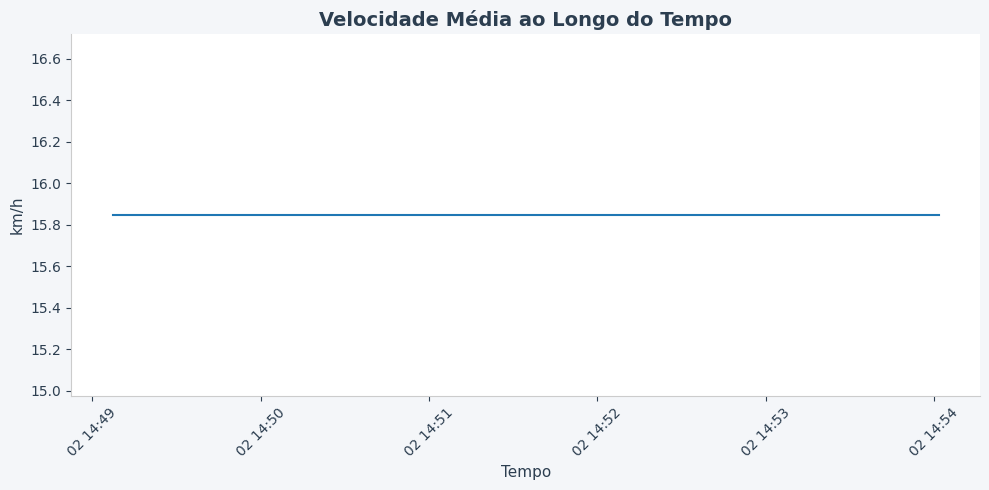

In [56]:
#Com o tempo de uso, podemos ler o histórico e visualizar a evolução das métricas
 
df_resumo = pd.read_csv(caminho, parse_dates=['timestamp'])

plt.figure(figsize=(10,5))

plt.plot(df_resumo['timestamp'], df_resumo['vel_media'])
plt.title('Velocidade Média ao Longo do Tempo')
plt.xlabel('Tempo')
plt.ylabel('km/h')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

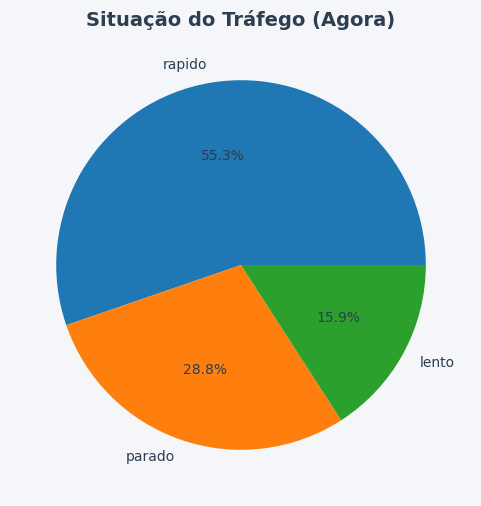

In [58]:
# =========================
# STATUS DE MOVIMENTO (VISÃO GERAL)
# =========================

status_dist = df_operacao['status_movimento'].value_counts(normalize=True) * 100

plt.figure(figsize=(6,6))

plt.pie(
    status_dist,
    labels=status_dist.index,
    autopct='%1.1f%%'
)

plt.title('Situação do Tráfego (Agora)')
plt.show()

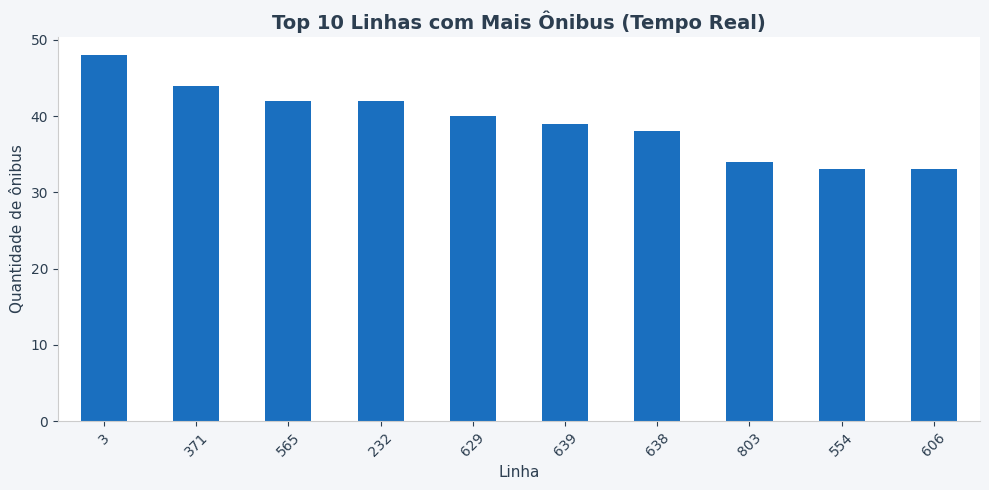

In [59]:
# =========================
# TOP LINHAS (ÔNIBUS ÚNICOS)
# =========================

top_linhas = (
    df_operacao.groupby('linha')['ordem']
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))

top_linhas.plot(kind='bar', color=AZUL)

plt.title('Top 10 Linhas com Mais Ônibus (Tempo Real)')
plt.ylabel('Quantidade de ônibus')
plt.xlabel('Linha')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

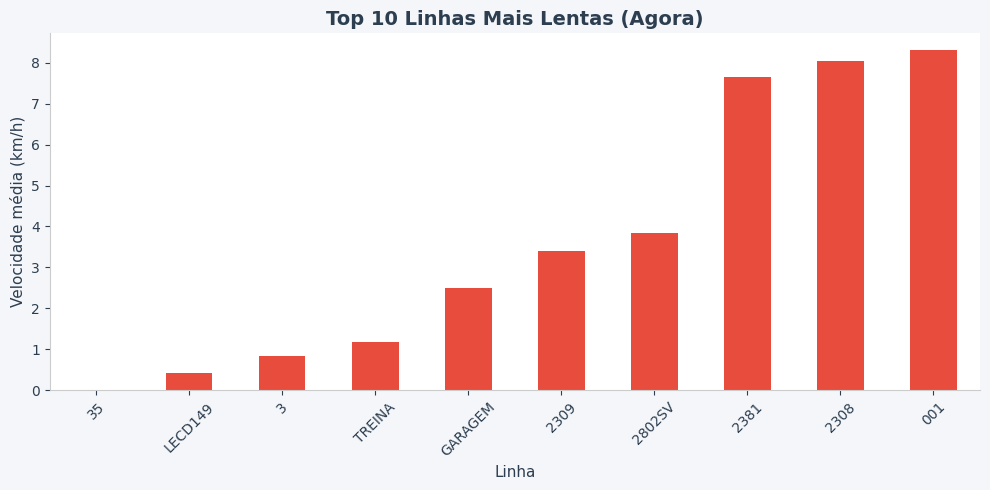

In [60]:
# =========================
# LINHAS MAIS LENTAS
# =========================

linhas_lentas = (
    df_operacao.groupby('linha')['velocidade']
    .mean()
    .sort_values()
    .head(10)
)

plt.figure(figsize=(10,5))

linhas_lentas.plot(kind='bar', color=VERMELHO)

plt.title('Top 10 Linhas Mais Lentas (Agora)')
plt.ylabel('Velocidade média (km/h)')
plt.xlabel('Linha')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

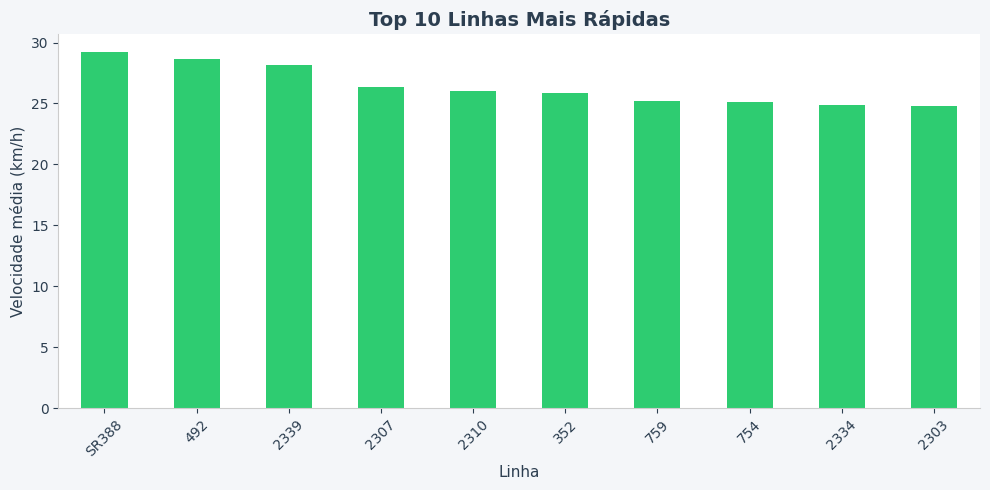

In [61]:
# =========================
# LINHAS MAIS RÁPIDAS
# =========================

linhas_rapidas = (
    df_operacao.groupby('linha')['velocidade']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))

linhas_rapidas.plot(kind='bar', color=VERDE)

plt.title('Top 10 Linhas Mais Rápidas')
plt.ylabel('Velocidade média (km/h)')
plt.xlabel('Linha')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

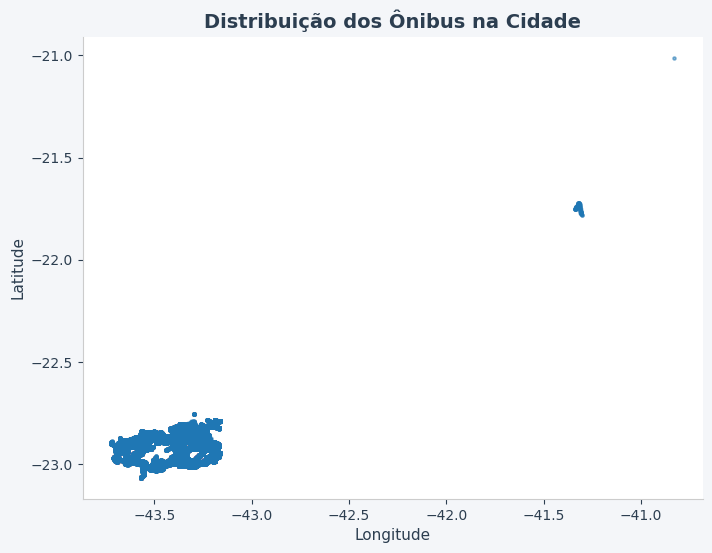

In [67]:
# =========================
# MAPA SIMPLES (SCATTER)
# =========================

plt.figure(figsize=(8,6))

plt.scatter(
    df_operacao['longitude'],
    df_operacao['latitude'],
    alpha=0.3,
    s=5
)

plt.title('Distribuição dos Ônibus na Cidade')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.show()